In this notebook I will compare two tracking algorithms for the **FPV drone tracking**. My task is to find algorthm that is the most suitable to work in conditions when FPV drones should be detected fast and precisely. Also occlusion and cross-pathing of several drones should not impact tracking. And it should work well with fast moving objects.

# Step 0. Setup the notebook

In [55]:
# !pip uninstall -y opencv-python opencv-contrib-python
# !pip install --no-cache-dir opencv-contrib-python==4.10.0.84

In [56]:
# load libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.rcParams['figure.figsize'] = [10, 15]

# Step 1. Load and show video

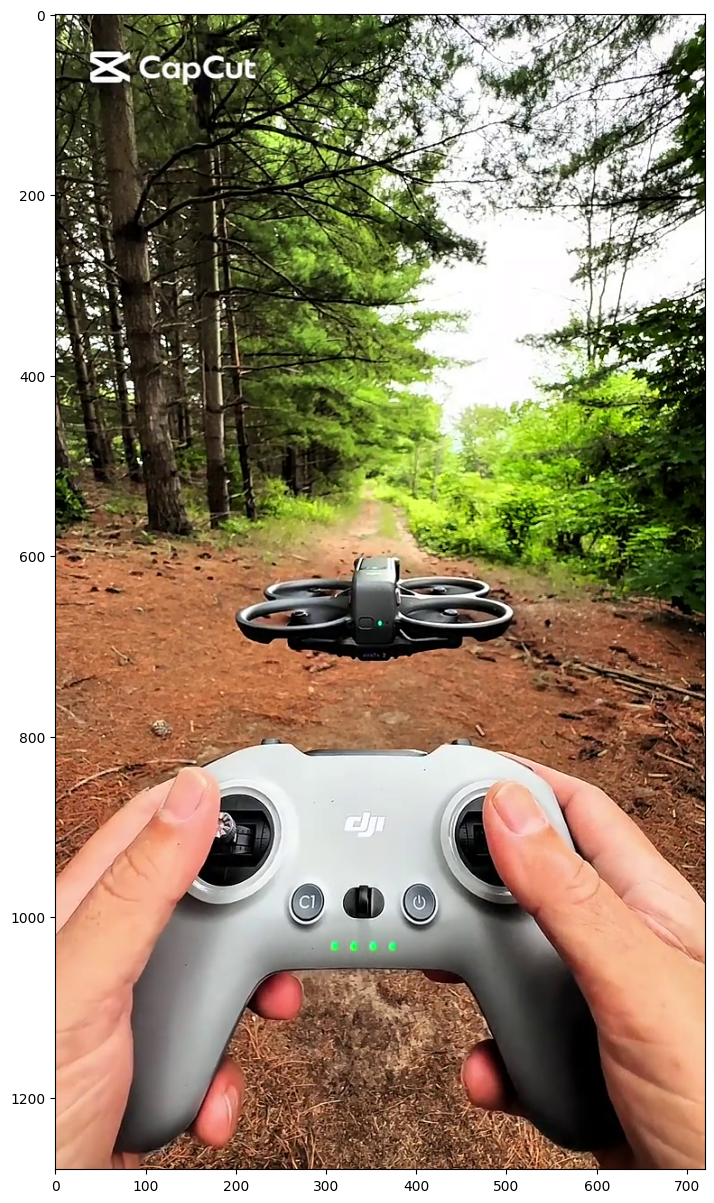

In [57]:
cap = cv2.VideoCapture('drone_tracking_1.mp4')

if not cap.isOpened():
  raise Exception("Video is not opened")

# show frame 50
cap.set(cv2.CAP_PROP_POS_FRAMES, 50)
ok, example_frame = cap.read()

if not ok:
  raise Exception("Video is not loaded")

example_frame = cv2.cvtColor(example_frame, cv2.COLOR_BGR2RGB)
plt.imshow(example_frame)

cap.release()

For the first tracker i choose CSRT. While it's not the fastest algorithm, it's robust to occlusions and can adapt to scale and appearence of object which is what i am looking for.

The second algorithm is MOSSE. In contrary with CSRT it's fast and can handle rapid motion but can fail if object appearence change. I hope it can be fixed with reapplying detection at the moments when it lose tracking.

Side note: while i chosed algoritms by myself the former information i got from ChatGPT :)

# Step 2. Initialize the tracker

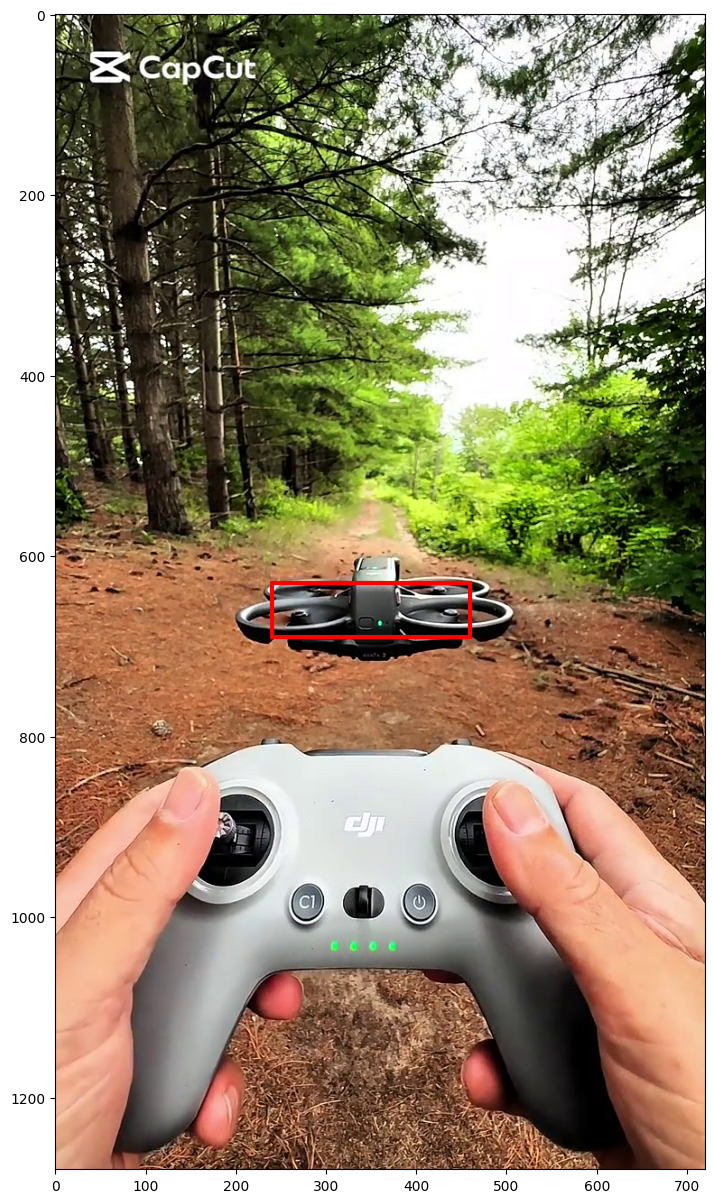

In [58]:
# drone detection coordinates

# define coordinates
bbox = (240, 630, 220, 60)
x, y, width, height = bbox

# draw rectangle for coordinates
rect = patches.Rectangle((x, y), width, height, linewidth=3, edgecolor='r', facecolor='none')
fig, ax = plt.subplots()
ax.imshow(example_frame)
ax.add_patch(rect)
plt.show()


Here i match not the whole drone but a part of it. If i try to cover the whole drone then the ground will be in the box and trackers will try to track it instead of drone.

In [59]:
# initialize trackers

# setup lists where results will be stored
frames = []
csrt_bboxes = []
mosse_bboxes = []

# iterate through frames
cap = cv2.VideoCapture('drone_tracking_1.mp4')

# start from specific frame
start_from_frame = 50
cap.set(cv2.CAP_PROP_POS_FRAMES, start_from_frame)
ok, frame_0 = cap.read()

#CSRT
csrt_tracker = cv2.TrackerCSRT_create()
csrt_tracker.init(frame_0, bbox)

# MOSSE
mosse_tracker = cv2.legacy.TrackerMOSSE_create()
mosse_tracker.init(frame_0, bbox)

while True:
  ret, frame = cap.read()

  if not ret:
    break

  csrt_ok, csrt_bbox = csrt_tracker.update(frame)
  mosse_ok, mosse_bbox = mosse_tracker.update(frame)

  frames.append(frame)
  csrt_bboxes.append(csrt_bbox if csrt_ok else None)
  mosse_bboxes.append(mosse_bbox if mosse_ok else None)

cap.release()

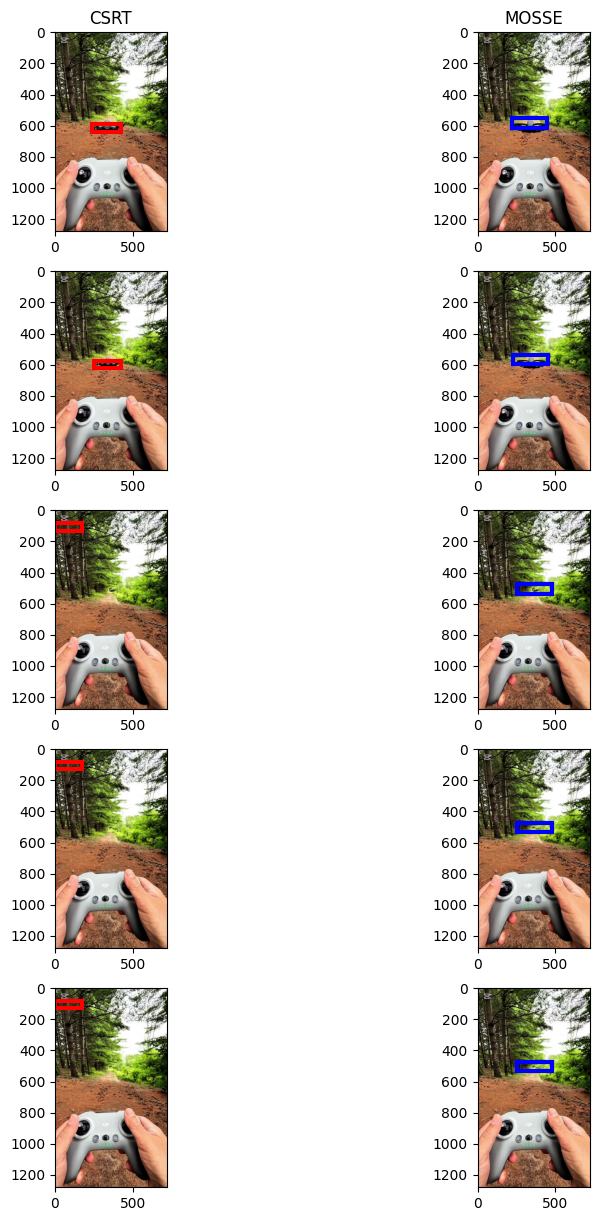

In [63]:
# get 5 random frames for comparison

import random

frame_numbers = random.sample(range(len(frames)), 5)
frame_numbers.sort()

# get subplot for drawing frames and rectangles
fig, ax = plt.subplots(5, 2)
ax[0][0].set_title('CSRT')
ax[0][1].set_title('MOSSE')

for i, n in enumerate(frame_numbers):
  frame = frames[n]
  frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
  csrt_bbox = csrt_bboxes[n]
  mosse_bbox = mosse_bboxes[n]

  x, y, width, height = csrt_bbox
  rect = patches.Rectangle((x, y), width, height, linewidth=3, edgecolor='r', facecolor='none')
  ax[i][0].imshow(frame)
  ax[i][0].add_patch(rect)

  x, y, width, height = mosse_bbox
  rect = patches.Rectangle((x, y), width, height, linewidth=3, edgecolor='b', facecolor='none')
  ax[i][1].imshow(frame)
  ax[i][1].add_patch(rect)

# Conclusions
If CSRT loose the drone at the frame it falsely identify region in the woods as tracked object. MOSSE loosing the object if it's going too far and falsely maps empty region where the drone was flying before. Both approaches can handle tracking if the size of the drone don't change drastically and require constant re-detection.

Also in order to make both detector work correctly I forced to match not the whole drone on the initiation image but the central part of it. If i try to match the whole drone than tracker will return coordinates of ground which would be captured in the box if the whole drone is matched.